In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import  train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import(accuracy_score,confusion_matrix,classification_report)


In [2]:
df=pd.read_excel("/content/Shipment_Risk_ Dataset.xlsx")
df

,Shipment_ID,Booking_Date,Origin,Destination,Shipping_Line,Container_Type,Commodity,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Port_Congestion,Weather,Insurance_Cost,Handling_Charges,Exchange_Rate,Customer_Priority,Freight_Cost,Shipment_Risk
0,100001,2026-01-01,Mundra,Dubai,MSC,20FT,Cardamom,22.23,1004.0,100.61,10,Low,Rain,1985,1416.0,84.43,Normal,51969.2,Medium
1,100002,2026-01-02,Kandla,Colombo,Hapag-Lloyd,20FT,Cardamom,20.98,6665.0,99.05,20,Low,Clear,1169,313.0,87.79,Urgent,91877.0,Medium
2,100003,2026-01-03,Mundra,Bangkok,Hapag-Lloyd,40FT,Chilli,13.64,3912.0,89.64,14,Medium,Fog,2094,1240.0,86.68,Normal,65762.8,Medium
3,100004,2026-01-04,Chennai,Singapore,Hapag-Lloyd,40FT,Cardamom,23.27,1175.0,99.24,12,High,Fog,2374,506.0,85.90,Urgent,53845.8,Medium
4,100005,2026-01-05,Kolkata,Singapore,Hapag-Lloyd,20FT,Cardamom,23.23,6399.0,99.02,22,Medium,Clear,1101,634.0,86.31,Normal,92927.4,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,100134,2026-05-14,Chennai,Bangkok,Hapag-Lloyd,40FT,Black Pepper,20.93,2642.0,104.01,12,Medium,Rain,2013,1743.0,86.45,Urgent,65140.2,Medium
1016,100105,2026-04-15,Chennai,Singapore,Hapag-Lloyd,20FT,Black Pepper,21.85,1449.0,88.32,9,High,Clear,2089,1546.0,86.64,Normal,51400.4,Medium
1017,100007,2026-01-07,Kolkata,Rotterdam,MSC,20FT,Black Pepper,23.92,5215.0,92.47,21,Low,Clear,1341,749.0,88.99,Normal,82567.4,Medium
1018,100601,2026-08-24,Nhava Sheva,Dubai,Hapag-Lloyd,20FT,Turmeric,27.22,6955.0,101.86,14,Low,Rain,2381,1273.0,86.57,Normal,106423.2,Medium


Exploratory Data Analysis (EDA)

In [3]:
df.shape

(1020, 19)

In [4]:
df.columns

Index(['Shipment_ID', 'Booking_Date', 'Origin', 'Destination', 'Shipping_Line',
       'Container_Type', 'Commodity', 'Weight_MT', 'Distance_KM', 'Fuel_Price',
       'Transit_Days', 'Port_Congestion', 'Weather', 'Insurance_Cost',
       'Handling_Charges', 'Exchange_Rate', 'Customer_Priority',
       'Freight_Cost', 'Shipment_Risk'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Shipment_ID        1020 non-null   int64  
 1   Booking_Date       1020 non-null   object 
 2   Origin             1020 non-null   object 
 3   Destination        1020 non-null   object 
 4   Shipping_Line      1020 non-null   object 
 5   Container_Type     1020 non-null   object 
 6   Commodity          1020 non-null   object 
 7   Weight_MT          1009 non-null   float64
 8   Distance_KM        1010 non-null   float64
 9   Fuel_Price         1020 non-null   float64
 10  Transit_Days       1020 non-null   int64  
 11  Port_Congestion    1020 non-null   object 
 12  Weather            1010 non-null   object 
 13  Insurance_Cost     1020 non-null   int64  
 14  Handling_Charges   1010 non-null   float64
 15  Exchange_Rate      1020 non-null   float64
 16  Customer_Priority  1020 

In [6]:
df.describe()

,Shipment_ID,Weight_MT,Distance_KM,Fuel_Price,Transit_Days,Insurance_Cost,Handling_Charges,Exchange_Rate,Freight_Cost
count,1020.000000,1009.000000,1010.000000,1020.000000,1020.000000,1020.000000,1010.000000,1020.000000,1020.000000
mean,100499.496078,19.927621,4119.109901,96.444686,14.303922,1545.681373,1033.253465,86.586176,75395.730588
std,289.213164,4.541128,2105.915815,4.938177,6.675559,558.169639,435.578814,1.417539,31707.480739
min,100001.000000,12.030000,821.000000,88.010000,3.000000,601.000000,300.000000,84.000000,39036.400000
25%,100249.750000,15.920000,2487.250000,92.055000,8.000000,1036.750000,644.000000,85.410000,60090.550000
50%,100497.500000,19.970000,4015.000000,96.320000,14.000000,1558.500000,1049.000000,86.590000,72277.600000
75%,100750.250000,23.610000,5638.250000,100.830000,20.000000,2013.000000,1402.750000,87.772500,84543.800000
max,101000.000000,28.000000,20682.000000,105.000000,25.000000,2500.000000,1800.000000,89.000000,398553.600000


In [7]:
df.dtypes

,0
Shipment_ID,int64
Booking_Date,object
Origin,object
Destination,object
Shipping_Line,object
Container_Type,object
Commodity,object
Weight_MT,float64
Distance_KM,float64
Fuel_Price,float64


Missing Values

In [8]:
df.isnull().sum()

,0
Shipment_ID,0
Booking_Date,0
Origin,0
Destination,0
Shipping_Line,0
Container_Type,0
Commodity,0
Weight_MT,11
Distance_KM,10
Fuel_Price,0


Fill Missing Values

In [9]:
#Numerical columns
num_col=df.select_dtypes(include=["int64","float64"]).columns
df[num_col]=df[num_col].fillna(df[num_col].mean())
#Categorical columns
cat_col=df.select_dtypes(include=["object"]).columns
df[cat_col]=df[cat_col].fillna(df[cat_col].mode().iloc[0])

In [10]:
#Check again
df.isnull().sum()

,0
Shipment_ID,0
Booking_Date,0
Origin,0
Destination,0
Shipping_Line,0
Container_Type,0
Commodity,0
Weight_MT,0
Distance_KM,0
Fuel_Price,0


Duplicate Records

In [11]:
df.duplicated().sum()

np.int64(19)

Remove duplicates

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
#Check again if duplicates exists
df.duplicated().sum()

np.int64(0)

Outlier Detection Using IQR

In [14]:
numeric_col=df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_col:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  df = df[(df[col] >= lower) & (df[col] <= upper)]


In [15]:
df.shape

(986, 19)

Visualizations

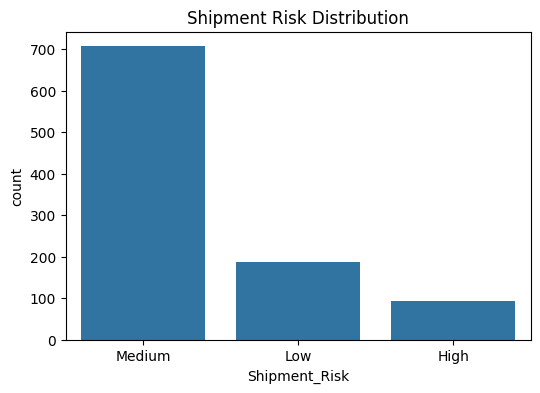

In [16]:
#Shipment Risk Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Shipment_Risk",data=df)
plt.title(("Shipment Risk Distribution"))
plt.show()

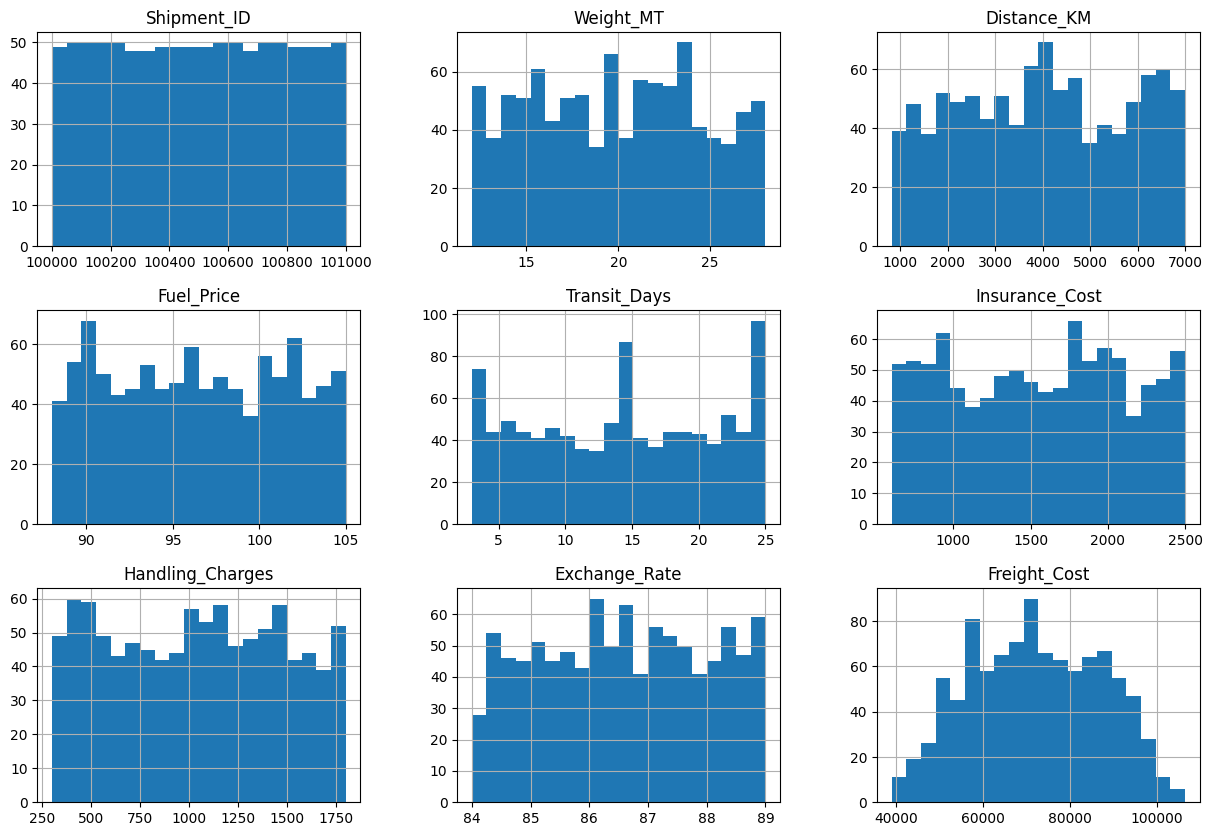

In [17]:
#Histogram
df.hist(figsize=(15,10),bins=20)
plt.show()

Boxplot

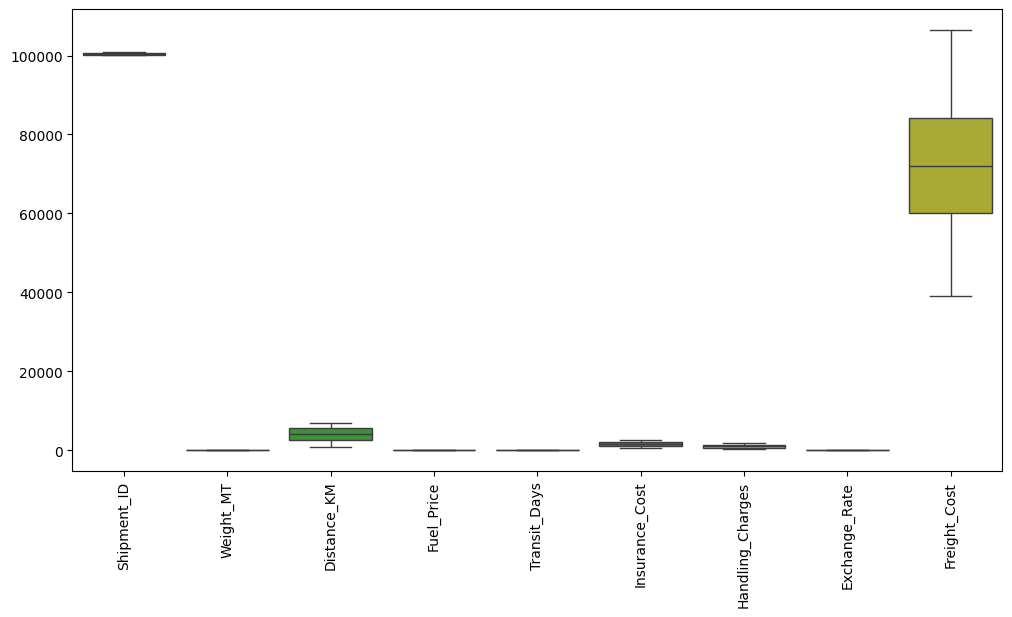

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=["int64","float64"]))
plt.xticks(rotation=90)
plt.show()

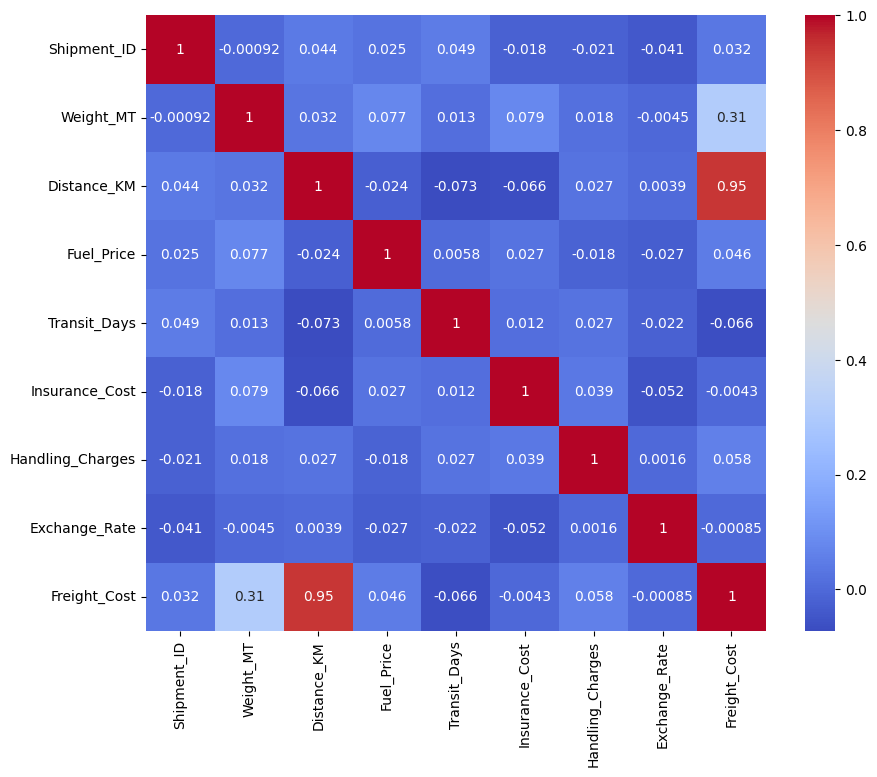

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=["int64","float64"]).corr(),annot=True,cmap="coolwarm")
plt.show()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 986 entries, 0 to 999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Shipment_ID        986 non-null    int64  
 1   Booking_Date       986 non-null    object 
 2   Origin             986 non-null    object 
 3   Destination        986 non-null    object 
 4   Shipping_Line      986 non-null    object 
 5   Container_Type     986 non-null    object 
 6   Commodity          986 non-null    object 
 7   Weight_MT          986 non-null    float64
 8   Distance_KM        986 non-null    float64
 9   Fuel_Price         986 non-null    float64
 10  Transit_Days       986 non-null    int64  
 11  Port_Congestion    986 non-null    object 
 12  Weather            986 non-null    object 
 13  Insurance_Cost     986 non-null    int64  
 14  Handling_Charges   986 non-null    float64
 15  Exchange_Rate      986 non-null    float64
 16  Customer_Priority  986 non-null

Feature Selection

In [21]:
x=df.drop(columns=['Shipment_ID','Booking_Date','Shipment_Risk'])
y=df['Shipment_Risk']

In [22]:
#cATEGORICAL_COLUMN
Categorical=x.select_dtypes(include='object').columns
print(Categorical)

Index(['Origin', 'Destination', 'Shipping_Line', 'Container_Type', 'Commodity',
       'Port_Congestion', 'Weather', 'Customer_Priority'],
      dtype='object')


In [23]:
#Column Transformer
preprocessor=ColumnTransformer(
[
("cat",OneHotEncoder(handle_unknown="ignore"),
 Categorical)],
remainder="passthrough")


In [24]:
model=Pipeline([
    ("preprocessor",preprocessor),
    ("Classifier",XGBClassifier(n_estimator=100,random_state=42))])

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df["Shipment_Risk"])

print(le.classes_)

['High' 'Low' 'Medium']


In [26]:
#Train-Test Split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [27]:
#Train the Model
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:08:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Origin', 'Destination', 'Shipping_Line', 'Container_Type', 'Commodity',
       'Port_Congestion', 'Weather', 'Customer_Priority'],
      dtype='object'))])),
                ('Classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimator=100, n_estimators=None, n_jobs=None, ...))])

In [28]:
prediction=model.predict(x_test)
print(prediction[:10])

[2 2 2 1 2 1 2 2 2 2]


Calculate Accuracy

In [29]:
accuracy=accuracy_score(y_test,prediction)
print("accuracy",accuracy)

accuracy 0.9646464646464646


In [30]:
confusion_matrix=confusion_matrix(y_test,prediction)
print("Confusion_matrix",confusion_matrix)

Confusion_matrix [[ 15   0   3]
 [  0  35   3]
 [  0   1 141]]


Classification Report

In [31]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.97      0.92      0.95        38
           2       0.96      0.99      0.98       142

    accuracy                           0.96       198
   macro avg       0.98      0.92      0.94       198
weighted avg       0.97      0.96      0.96       198



In [32]:
#predict new shipment

new_data = pd.DataFrame({
    'Container_Type': ['20FT'],
    'Origin': ['Mumbai'],
    'Destination': ['Chennai'],
    'Commodity': ['Spices'],
    'Shipping_Line': ['Maersk'],
    'Distance_KM': [1350],
    'Weight_MT': [22],
    'Freight_Cost': [85000],
    'Insurance_Cost': [2500],
    'Handling_Charges': [1800],
    'Fuel_Price': [95],
    'Exchange_Rate': [83.5],
    'Weather': ['Clear'],
    'Port_Congestion': ['Low'],
    'Customer_Priority': ['High'],
    'Transit_Days': [5]
})

risk = model.predict(new_data)

risk = le.inverse_transform(risk)

print("Predicted Shipment Risk:", risk[0])

Predicted Shipment Risk: Low
